# <center> Predicción de Precios en Bienes Raíces - Mercado Australiano - Regresión Avanzada con PyCaret

# Tabla de Contenido

1. [Introducción](#Introducción)
2. [Configuración e Instalación](#Configuración-e-Instalación)
3. [Entendimiento de los Datos](#Entendimiento-de-los-Datos)  
4. [Manipulación y Limpieza de Datos](#Manipulación-y-Limpieza-de-Datos)
    1. [Dropping Data](#Dropping-Data)
    2. [Derived Data](#Derived-Data)
5. [Análisis de Datos](#Análisis-de-Datos)
    1. [Análisis-Univariable](#Análisis-Univariable)
        1. [Plot Numeric Data](#Plot-Numeric-Data)
        2. [Plot Categorical Data](#Plot-Categorical-Data)
    2. [Análisis-Bivariable](#Análisis-Bivariable)
6. [Preparación de Datos y Modelado](#Preparación-de-Datos-y-Modelado)
    1. [Splitting data into Train Test](#Splitting-data-into-Train-Test)
7. [Construcción-del-Modelo](#Model-Building)
    1. [Ridge Regression](#Ridge-Regression)
    2. [Lasso Regression](#Lasso-Regression)
    3. [ElasticNet Regression](#ElasticNet-Regression)
8. [Conclusiones y Observaciones](#Conclusiones-y-Observaciones)

# Introducción

### Integrantes del Grupo:
* De los Rios Aliaga, Mijaelha
* Flores Velasquez, Maritza Karen
* Machaca Lamas, Sergio Alejandro
* Mamani Poma, Alexander Manuel
* Vilela, Bruno



## Entendimiento del Negocio

Una empresa de vivienda con sede en EE. UU. llamada Surprise Housing ha decidido ingresar al mercado australiano. La empresa utiliza el análisis de datos para comprar casas a un precio inferior a sus valores reales y venderlas a un precio más alto. Con el mismo propósito, la empresa ha recopilado un conjunto de datos de la venta de casas en Australia. Los datos se proporcionan en el archivo CSV a continuación.

La compañía está buscando posibles propiedades para comprar e ingresar al mercado. Debe construir un modelo de regresión utilizando la regularización para predecir el valor real de las posibles propiedades y decidir si invertir en ellas o no.

La empresa quiere saber:

* Qué variables son significativas para predecir el precio de una casa, y
* Qué tan bien esas variables describen el precio de una casa.

Además, determine el valor óptimo de lambda para la regresión de Ridge y Lasso.

### Objetivo del Negocio:

Debe modelar el precio de las casas con las variables independientes disponibles. Luego, la gerencia utilizará este modelo para comprender cómo varían exactamente los precios con las variables. En consecuencia, pueden manipular la estrategia de la empresa y concentrarse en áreas que generarán altos rendimientos. Además, el modelo será una buena manera para que la gerencia entienda la dinámica de precios de un nuevo mercado.

# Configuración e Instalación

In [1]:
# Instalar PyCaret 4.0 (compatible con Python 3.12 de Colab)
!pip install git+https://github.com/pycaret/pycaret.git@v4.0.0a0 -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.9/630.9 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the 

In [2]:
# Importar Librerías Requeridas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab
import seaborn as sns
import sys
import pycaret

# Importar Librerías de Machine Learning
import sklearn
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Importar Librerías de Estadística
import statsmodels.api as stats
from statsmodels.api import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# Ignorar Alertas (Warnings)
import warnings
warnings.filterwarnings('ignore')

# Definir precisión del FLOAT a dos dígitos.
pd.options.display.float_format = '{:.2f}'.format

In [3]:
# Leer el DATASET CSV con en un Dataframe.
# Funciona en local (ruta relativa desde la raiz del repositorio) y en Google Colab (solicita la subida del archivo)
import os

# Dirección relativa del Dataset
DATA_FILE_PATH = '_data/dataset.csv'

EN_COLAB = 'google.colab' in sys.modules

if not os.path.exists(DATA_FILE_PATH):
    if EN_COLAB:
        from google.colab import files
        os.makedirs('_data', exist_ok=True)
        print('Sube el archivo dataset.csv:')
        subidos = files.upload()
        os.rename(list(subidos.keys())[0], DATA_FILE_PATH)
    else:
        raise FileNotFoundError(
            f'No se encontro {DATA_FILE_PATH}. Ejecuta el notebook desde la raiz del repositorio.')

raw_data = pd.read_csv(DATA_FILE_PATH)
print(raw_data.shape)

(1460, 81)


# Entendimiento de los Datos
### Dimensiones y Estructura del Dataset

In [4]:
# Ver dimensiones del dataset (filas, columnas)
print(raw_data.shape)
raw_data.info()

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

### Primeras Filas del Dataset

In [5]:
# Ver las primeras filas del dataset
raw_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Estadísticas Descriptivas

In [6]:
# Estadisticas descriptivas de variables numericas
raw_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.00,1460.00,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,...,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,730.50,56.90,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,...,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82,180921.20
std,421.61,42.30,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,...,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33,79442.50
min,1.00,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,34900.00
25%,365.75,20.00,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00,129975.00
50%,730.50,50.00,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,...,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,163000.00
75%,1095.25,70.00,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,...,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,214000.00
max,1460.00,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,...,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00,755000.00


### Variable Objetivo: SalePrice

In [7]:
# Estadisticas de la variable objetivo
raw_data['SalePrice'].describe()

,SalePrice
count,1460.00
mean,180921.20
std,79442.50
min,34900.00
25%,129975.00
50%,163000.00
75%,214000.00
max,755000.00


### Valores Faltantes

In [8]:
# Ver cantidad de valores faltantes por columna
missing = raw_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


## Manipulación y Limpieza de Datos

### Dropping Data

In [9]:
# Eliminar columna Id, no aporta informacion para el modelo
df = raw_data.drop(columns=['Id'])

In [10]:
# Eliminar columnas con demasiados valores faltantes (mas del 80%)
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
df = df.drop(columns=cols_to_drop)
print(df.shape)

(1460, 76)


In [11]:
# Verificar duplicados
print(df.duplicated().sum())

0


### Derived Data

In [12]:
# Rellenar valores NA que representan "sin caracteristica" segun el diccionario de datos
cols_none = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df[cols_none] = df[cols_none].fillna('None')

In [13]:
# Rellenar valores numericos faltantes con la mediana o cero segun corresponda
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [14]:
# Eliminar las pocas filas restantes con valores faltantes (Electrical)
df = df.dropna()
print(df.shape)
print(df.isnull().sum().sum())

(1459, 76)
0


# Análisis de Datos

Con el dataset ya limpio (1459 filas x 76 columnas) se explora el comportamiento de las variables antes de modelar. El objetivo es identificar la forma de la distribución de la variable objetivo, detectar valores atípicos y multicolinealidad, y reconocer qué variables se relacionan con el precio de venta.

In [15]:
# Separar las variables numericas y categoricas para el analisis
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables numericas  : {len(num_cols)}')
print(f'Variables categoricas: {len(cat_cols)}')

Variables numericas  : 37
Variables categoricas: 39


## Análisis Univariable

### Plot Numeric Data

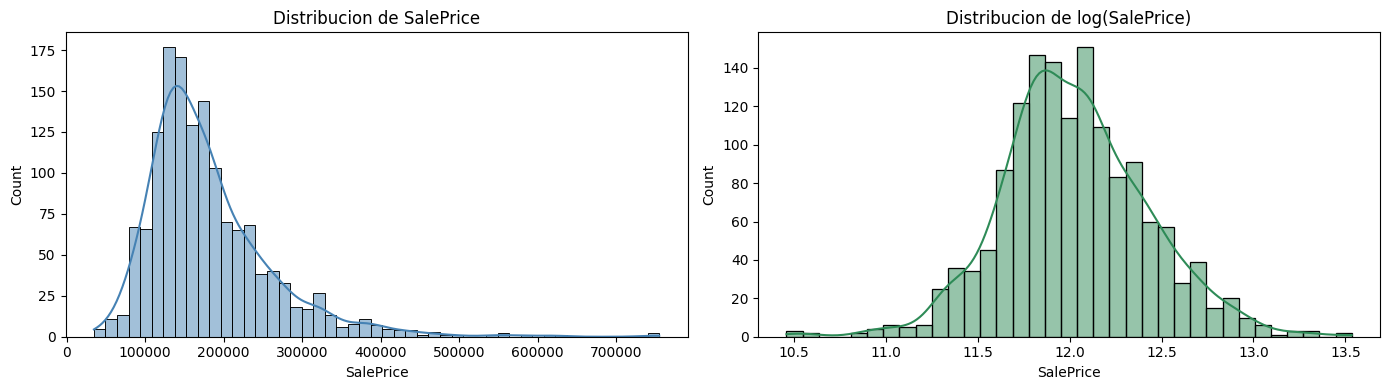

Asimetria (skew) original : 1.8819
Curtosis original         : 6.5293
Asimetria con log1p       : 0.1213


In [16]:
# Distribucion de la variable objetivo, en escala original y logaritmica
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribucion de SalePrice')
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribucion de log(SalePrice)')
plt.tight_layout()
plt.show()

print(f"Asimetria (skew) original : {df['SalePrice'].skew():.4f}")
print(f"Curtosis original         : {df['SalePrice'].kurt():.4f}")
print(f"Asimetria con log1p       : {np.log1p(df['SalePrice']).skew():.4f}")

La variable `SalePrice` presenta una asimetría positiva marcada (1.88) y colas pesadas: la media (180 930) supera a la mediana (163 000) y el máximo llega a 755 000. Al aplicar una transformación logarítmica la asimetría baja a 0.12, es decir, la distribución se vuelve prácticamente simétrica. Esto es relevante porque la regresión lineal asume residuos normales.

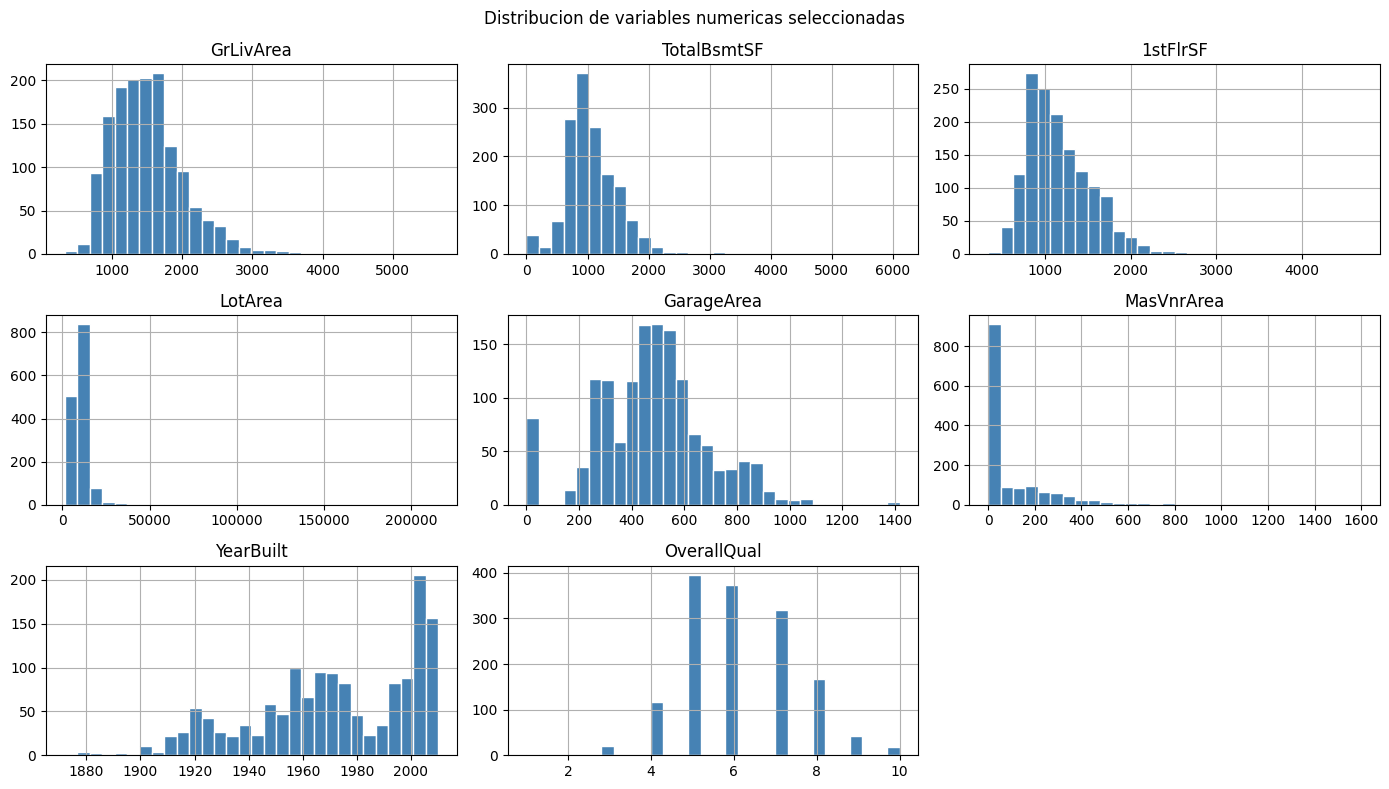

In [17]:
# Distribucion de las principales variables numericas continuas
vars_num = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'LotArea',
            'GarageArea', 'MasVnrArea', 'YearBuilt', 'OverallQual']
df[vars_num].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribucion de variables numericas seleccionadas')
plt.tight_layout()
plt.show()

In [18]:
# Variables numericas con mayor asimetria (candidatas a transformacion)
asimetria = df[num_cols].drop(columns=['SalePrice']).skew().sort_values(ascending=False)
print(asimetria.head(10))

MiscVal         24.47
PoolArea        14.82
LotArea         12.20
3SsnPorch       10.30
LowQualFinSF     9.01
KitchenAbvGr     4.49
BsmtFinSF2       4.25
ScreenPorch      4.12
BsmtHalfBath     4.10
EnclosedPorch    3.09
dtype: float64


Varias variables numéricas están fuertemente sesgadas porque son en realidad *conteos de una característica que la mayoría de las viviendas no posee*: `MiscVal` (24.47), `PoolArea` (14.82) y `3SsnPorch` (10.30) son casi siempre cero. `LotArea` (12.20) sí es continua, pero con unos pocos terrenos enormes que estiran la cola.

### Plot Categorical Data

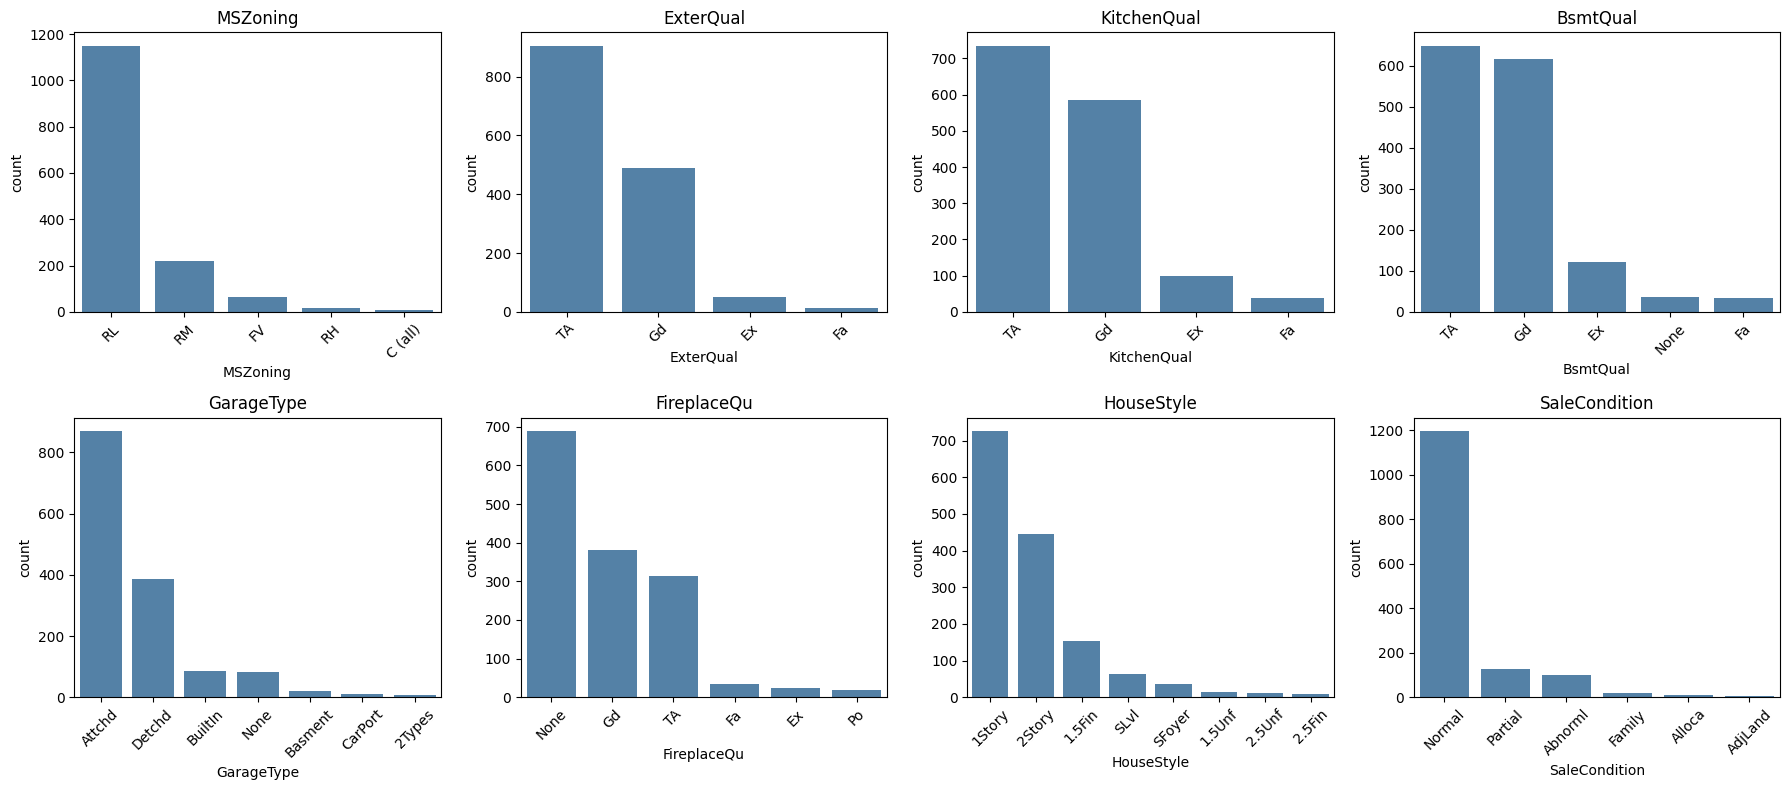

In [19]:
# Frecuencia de las principales variables categoricas
vars_cat = ['MSZoning', 'ExterQual', 'KitchenQual', 'BsmtQual',
            'GarageType', 'FireplaceQu', 'HouseStyle', 'SaleCondition']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), vars_cat):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Variables categoricas dominadas por una sola categoria (aportan poca informacion)
for col in cat_cols:
    prop = df[col].value_counts(normalize=True).iloc[0]
    if prop > 0.95:
        print(f'{col:15} -> {df[col].value_counts().index[0]:10} {prop * 100:.1f}%')

Street          -> Pave       99.6%
Utilities       -> AllPub     99.9%
Condition2      -> Norm       99.0%
RoofMatl        -> CompShg    98.2%
Heating         -> GasA       97.8%


Cinco variables categóricas son prácticamente constantes: `Utilities` (99.9% `AllPub`), `Street` (99.6% `Pave`), `Condition2` (99.0% `Norm`), `RoofMatl` (98.2% `CompShg`) y `Heating` (97.8% `GasA`). Al no presentar variabilidad, no pueden explicar diferencias de precio y son candidatas a eliminarse antes del modelado.

## Análisis Bivariable

In [21]:
# Correlacion de las variables numericas con SalePrice
corr_target = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print('Top 10 correlaciones positivas:')
print(corr_target.head(10))
print('\nTop 5 correlaciones negativas:')
print(corr_target.tail(5))

Top 10 correlaciones positivas:
OverallQual    0.79
GrLivArea      0.71
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
FullBath       0.56
TotRmsAbvGrd   0.53
YearBuilt      0.52
YearRemodAdd   0.51
Name: SalePrice, dtype: float64

Top 5 correlaciones negativas:
YrSold          -0.03
OverallCond     -0.08
MSSubClass      -0.08
EnclosedPorch   -0.13
KitchenAbvGr    -0.14
Name: SalePrice, dtype: float64


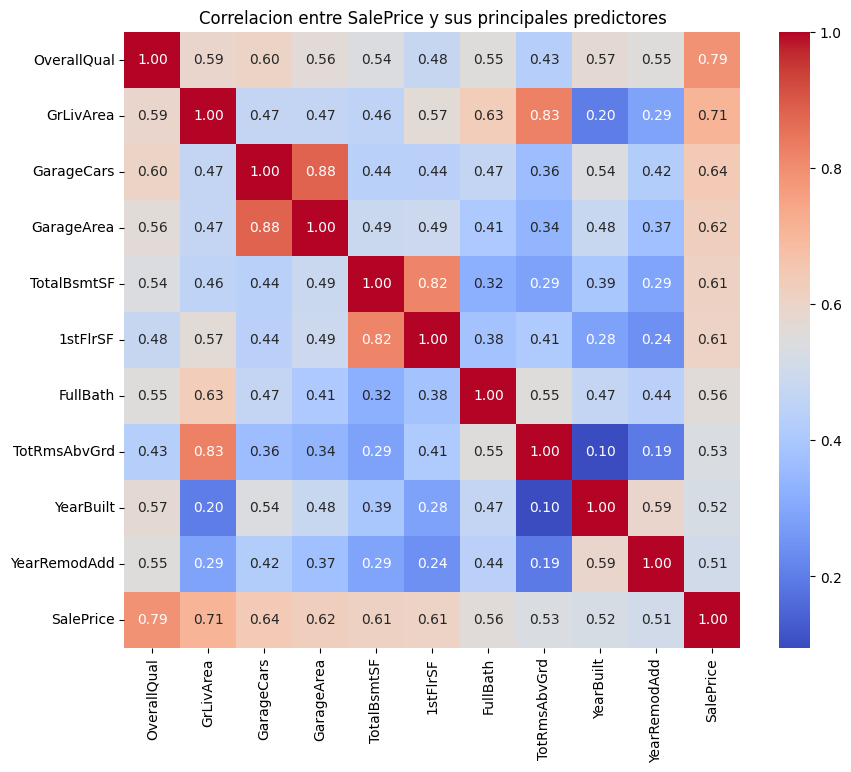

In [22]:
# Mapa de calor de las variables mas correlacionadas con SalePrice
top_corr = corr_target.abs().sort_values(ascending=False).head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlacion entre SalePrice y sus principales predictores')
plt.show()

Las variables numéricas más correlacionadas con el precio son `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62) y `TotalBsmtSF` (0.61): la calidad general y la superficie habitable son los factores dominantes. Las correlaciones negativas son todas débiles, la mayor en valor absoluto es `KitchenAbvGr` (-0.14).

In [23]:
# Pares de variables numericas muy correlacionadas entre si (multicolinealidad)
corr_num = df[num_cols].drop(columns=['SalePrice']).corr().abs()
pares = corr_num.where(np.triu(np.ones(corr_num.shape), k=1).astype(bool)).stack()
print(pares[pares > 0.7].sort_values(ascending=False))

GarageCars   GarageArea     0.88
GrLivArea    TotRmsAbvGrd   0.83
TotalBsmtSF  1stFlrSF       0.82
dtype: float64


Se detectan tres pares con correlación superior a 0.7 que miden esencialmente lo mismo: `GarageCars` ~ `GarageArea` (0.883), `GrLivArea` ~ `TotRmsAbvGrd` (0.826) y `TotalBsmtSF` ~ `1stFlrSF` (0.819). Esta multicolinealidad justifica el uso de regularización y deberá revisarse con el VIF en la etapa de selección de características.

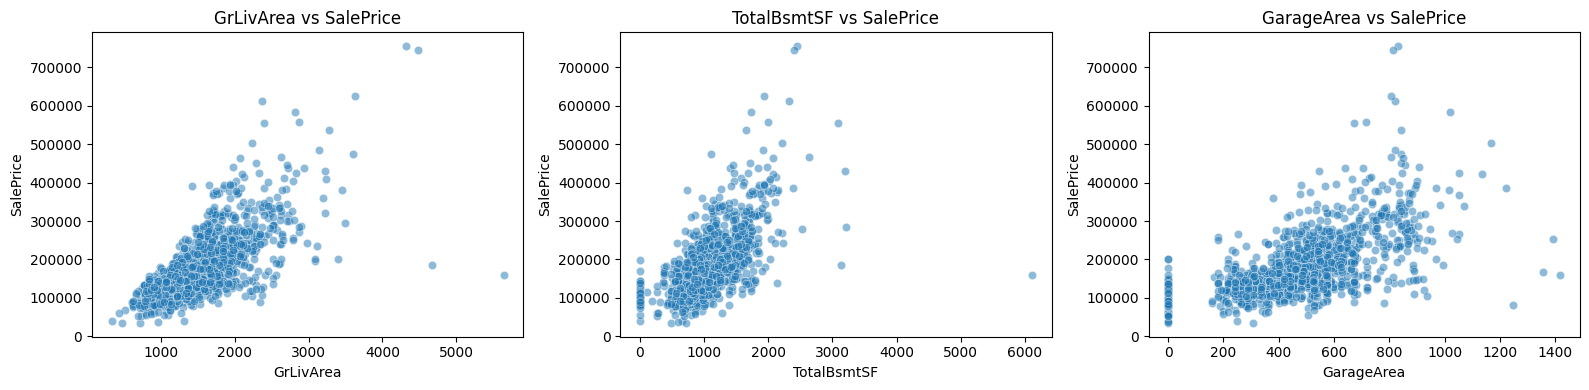

Viviendas con GrLivArea > 4000 y precio < 300000:
      GrLivArea  OverallQual  SalePrice
523        4676           10     184750
1298       5642           10     160000


In [24]:
# Relacion entre las principales variables continuas y SalePrice
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['GrLivArea', 'TotalBsmtSF', 'GarageArea']):
    sns.scatterplot(data=df, x=col, y='SalePrice', ax=ax, alpha=0.5)
    ax.set_title(f'{col} vs SalePrice')
plt.tight_layout()
plt.show()

# Viviendas muy grandes con un precio anormalmente bajo (posibles valores atipicos)
atipicos = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print('Viviendas con GrLivArea > 4000 y precio < 300000:')
print(atipicos[['GrLivArea', 'OverallQual', 'SalePrice']])

La relación entre `GrLivArea` y `SalePrice` es claramente lineal y creciente, salvo por dos observaciones con superficies superiores a 4000 pies cuadrados y calidad máxima (`OverallQual` = 10) vendidas por debajo de 185 000. Son ventas atípicas que conviene tener presentes, ya que pueden afectar de forma desproporcionada a los coeficientes de la regresión.

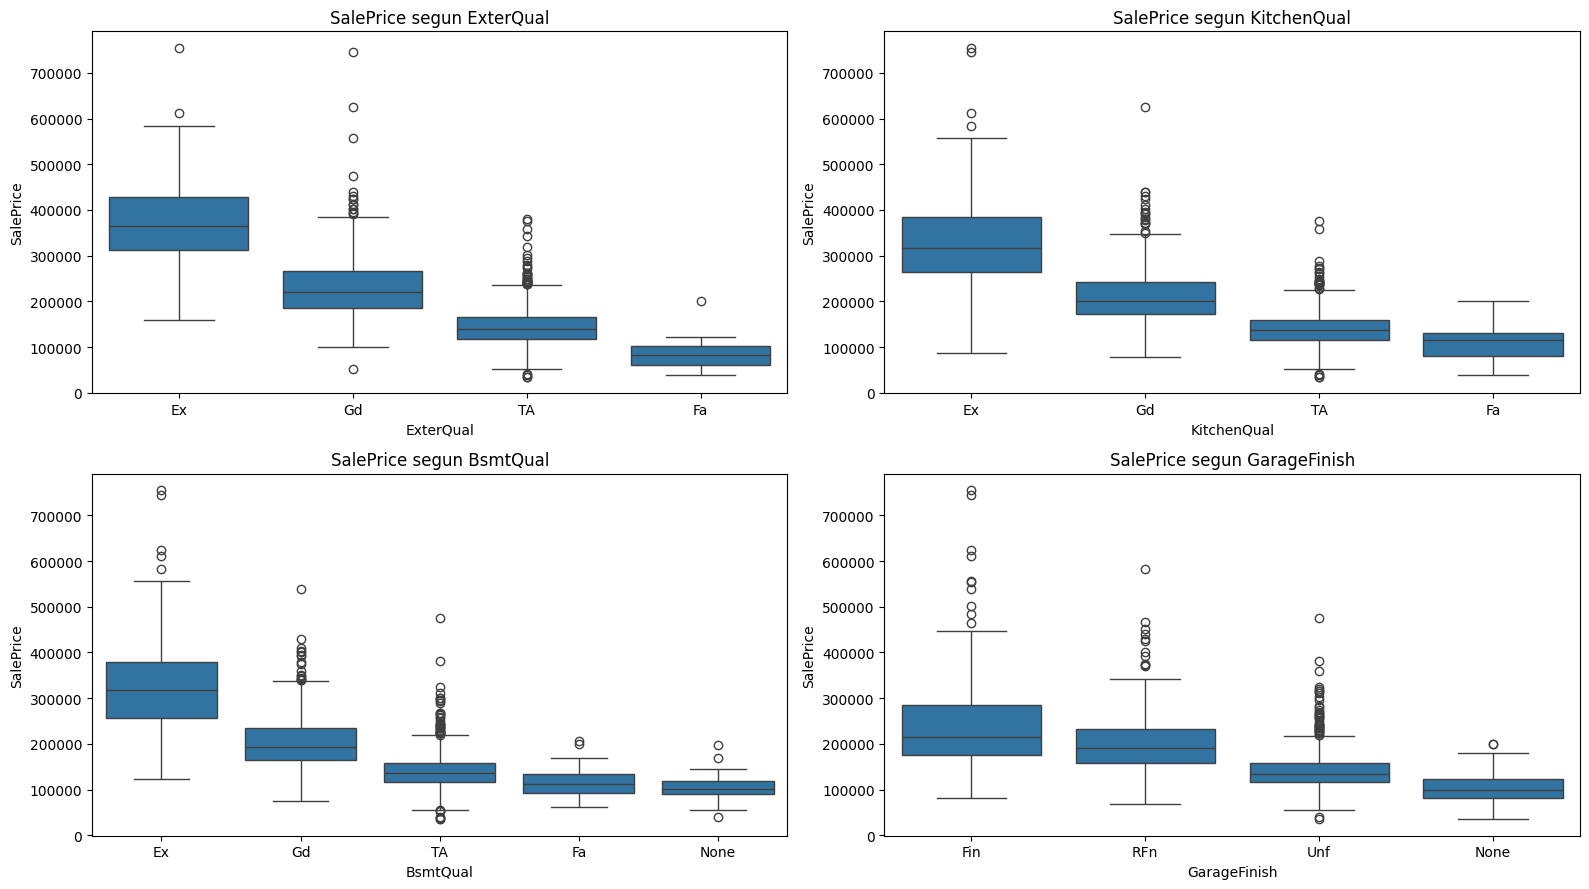

In [25]:
# Distribucion de SalePrice segun las principales variables categoricas
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, col in zip(axes.flatten(), ['ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish']):
    orden = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='SalePrice', order=orden, ax=ax)
    ax.set_title(f'SalePrice segun {col}')
plt.tight_layout()
plt.show()

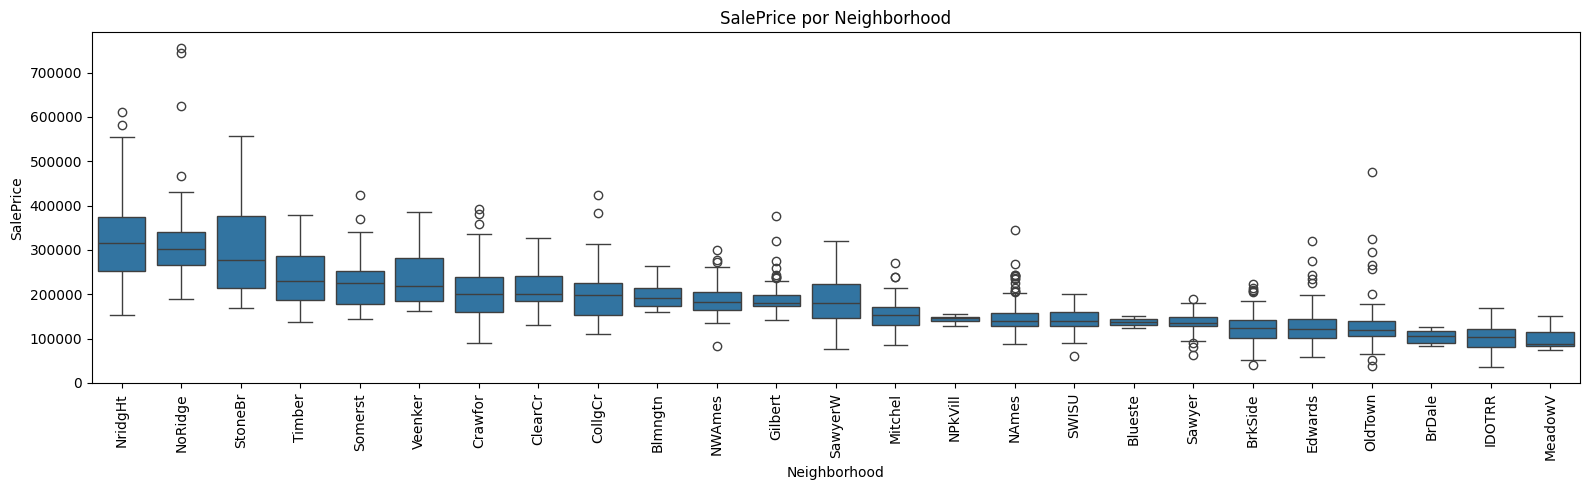

In [26]:
# SalePrice por vecindario, la categorica con mayor poder explicativo
orden = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
plt.figure(figsize=(16, 5))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=orden)
plt.xticks(rotation=90)
plt.title('SalePrice por Neighborhood')
plt.tight_layout()
plt.show()

In [27]:
# Poder explicativo de cada variable categorica sobre SalePrice (eta cuadrado)
media_global = df['SalePrice'].mean()
sst = ((df['SalePrice'] - media_global) ** 2).sum()

eta2 = {}
for col in cat_cols:
    grupos = df.groupby(col)['SalePrice']
    ssb = (grupos.count() * (grupos.mean() - media_global) ** 2).sum()
    eta2[col] = ssb / sst

eta2 = pd.Series(eta2).sort_values(ascending=False)
print(eta2.head(10))

Neighborhood   0.55
ExterQual      0.48
BsmtQual       0.47
KitchenQual    0.46
GarageFinish   0.31
FireplaceQu    0.29
Foundation     0.26
GarageType     0.25
BsmtFinType1   0.21
HeatingQC      0.20
dtype: float64


El estadístico eta cuadrado mide qué proporción de la varianza de `SalePrice` explica cada variable categórica por sí sola. `Neighborhood` encabeza la lista con 0.546, seguida de las variables de calidad `ExterQual` (0.477), `BsmtQual` (0.465) y `KitchenQual` (0.457). La ubicación y la calidad de los acabados son, por tanto, los factores categóricos determinantes del precio.

### Resumen del Análisis

* `SalePrice` tiene asimetría positiva (1.88); la transformación logarítmica la reduce a 0.12 y normaliza la distribución.
* Los predictores numéricos más fuertes son `OverallQual` (r = 0.79) y `GrLivArea` (r = 0.71).
* Los predictores categóricos más fuertes son `Neighborhood` (eta² = 0.546) y las variables de calidad `ExterQual`, `BsmtQual` y `KitchenQual`.
* Existe multicolinealidad relevante en tres pares de variables, lo que respalda el uso de modelos regularizados.
* Cinco variables categóricas son casi constantes y aportan poca información.
* Se identificaron dos ventas atípicas de viviendas grandes a precio bajo.

# Preparación de Datos y Modelado

A partir de los hallazgos del análisis exploratorio, se prepara el dataset para el modelado y se divide en conjuntos de **entrenamiento** y **prueba**. Las decisiones que se aplican antes del split son:

1. **Eliminar variables categóricas casi constantes** (`Utilities`, `Street`, `Condition2`, `RoofMatl`, `Heating`): aportan poca información.
2. **Eliminar las dos ventas atípicas** con `GrLivArea > 4000` y `SalePrice < 300000`: distorsionan los coeficientes de la regresión.
3. **Transformar la variable objetivo** con `log1p(SalePrice)`: reduce la asimetría de 1.88 a ~0.12 y acerca los residuos a normalidad.
4. **Codificar las variables categóricas** restantes con *one-hot encoding* (`pd.get_dummies`), necesario para Ridge / Lasso / ElasticNet.
5. **Separar train/test** (80 % / 20 %) con `random_state` fijo para reproducibilidad.

> **Alcance de esta sección:** deja listos `X_train`, `X_test`, `y_train` y `y_test`. El escalado (`StandardScaler`), la selección de características (RFE / VIF) y el entrenamiento de Ridge, Lasso y ElasticNet corresponden a la **sección 7 — Construcción del Modelo**.

In [ ]:
# Aplicar las decisiones del EDA antes de separar train/test
df_model = df.copy()

# 1) Variables categoricas casi constantes (poca informacion)
cols_baja_variabilidad = ['Utilities', 'Street', 'Condition2', 'RoofMatl', 'Heating']
df_model = df_model.drop(columns=cols_baja_variabilidad)

# 2) Dos ventas atipicas: casas muy grandes vendidas a precio anormalmente bajo
n_antes = len(df_model)
df_model = df_model[~((df_model['GrLivArea'] > 4000) & (df_model['SalePrice'] < 300000))]
print(f'Filas eliminadas por atipicos: {n_antes - len(df_model)}')

# 3) Variable objetivo en escala logaritmica
df_model['SalePrice_Log'] = np.log1p(df_model['SalePrice'])

print(f'Dataset listo para modelar: {df_model.shape[0]} filas x {df_model.shape[1]} columnas')
print(f"Asimetria de SalePrice_Log: {df_model['SalePrice_Log'].skew():.4f}")
df_model.head()

## Splitting data into Train Test

Se separan predictores (`X`) y objetivo (`y = SalePrice_Log`), se codifican las categóricas y se realiza un *hold-out* del **20 %** para prueba. El escalado de features **no** se aplica aquí: debe hacerse *después* del split, ajustando el scaler **solo con train**, para evitar fuga de información (*data leakage*). Eso queda para la sección 7.

In [ ]:
# Separar predictores y objetivo (y en escala log)
y = df_model['SalePrice_Log']
X = df_model.drop(columns=['SalePrice', 'SalePrice_Log'])

# One-hot encoding de variables categoricas (drop_first evita multicolinealidad perfecta con la categoria base)
X = pd.get_dummies(X, drop_first=True)

print(f'Features tras one-hot encoding: {X.shape[1]}')
print(f'Numericas originales + dummies. Ejemplo de columnas:')
print(list(X.columns[:8]), '...')

# Division 80/20 reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('\n--- Tamanos del split ---')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   |  y_test : {y_test.shape}')
print(f'Proporcion test: {len(X_test) / len(X):.1%}')
print(f'\nMedia y_train (log): {y_train.mean():.4f}  |  Media y_test (log): {y_test.mean():.4f}')

In [ ]:
# Vista rapida: distribucion del objetivo en train vs test (misma escala log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.histplot(y_train, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('y_train = log1p(SalePrice)')
sns.histplot(y_test, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('y_test = log1p(SalePrice)')
plt.tight_layout()
plt.show()

# Objetos que deja lista esta seccion para la Construccion del Modelo (seccion 7)
print('Variables disponibles para la seccion 7:')
print('  X_train, X_test, y_train, y_test')
print('  X, y              # matrices completas (por si se usa validacion cruzada sobre todo el set)')
print('  df_model          # dataframe previo al encoding, con SalePrice y SalePrice_Log')
print('  feature_names     # nombres de columnas de X')
feature_names = X.columns.tolist()
print(f'  -> {len(feature_names)} features')

### Entrega al punto 7 — Construcción del Modelo

La sección 6 deja el pipeline en este estado:

| Objeto | Descripción |
|---|---|
| `X_train`, `y_train` | 80 % de los datos para entrenar y tunear λ |
| `X_test`, `y_test` | 20 % reservado solo para evaluación final |
| `y_*` | Ya está en **`log1p(SalePrice)`** — al reportar precios reales usar `np.expm1(...)` |
| `X_*` | Numérico, con dummies (`drop_first=True`); **sin escalar todavía** |

**Pasos sugeridos para la sección 7** (según el README del repo):

1. **Escalado** con `StandardScaler`: `fit` solo en `X_train`, luego `transform` en train y test.
2. **Selección de características** con RFE y revisión de multicolinealidad (VIF).
3. Entrenar y comparar **Ridge**, **Lasso** y **ElasticNet** (GridSearchCV / KFold para el λ óptimo).
4. Evaluar con **R²** y **RMSE** (en escala log y, si se desea, retransformando a precio).
5. Análisis de residuos y variables más significativas (coeficientes).
6. Completar las conclusiones del README (λ óptimo, métricas, variables clave).

> No re-ejecutar el split con otro `random_state` si se quiere comparar modelos sobre el mismo hold-out.

# Construcción del Modelo

> **Pendiente — sección 7.** Continuar a partir de `X_train`, `X_test`, `y_train`, `y_test` definidos en la sección 6.

## Ridge Regression

## Lasso Regression

## ElasticNet Regression